In [21]:
import pandas as pd
import numpy as np
import joblib
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from keras.models import load_model
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# 1. Load and preprocess dataset (LIMITED TO 10K rows)
df = pd.read_csv("Reviews.csv")
df = df[['Score', 'Text']].dropna()
df = df[df['Score'] != 3]
df = df.sample(n=10000, random_state=42).reset_index(drop=True)  # Limit for speed

df['Sentiment'] = df['Score'].apply(lambda x: 1 if x < 3 else 0)  # 1 = Negative, 0 = Positive

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r"\d+", "", text)
    return text

df['Clean_Text'] = df['Text'].apply(clean_text)

In [23]:
# 2. TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf.fit_transform(df['Clean_Text'])
y = df['Sentiment'].values

In [24]:
# 2. Load models
lr = joblib.load("models/logisticregression_sentiment_model.pkl")
svm = joblib.load("models/svm_sentiment_model.pkl")
xgb = joblib.load("models/xgboost_sentiment_model.pkl")

cnn = load_model("cnn_model.h5")
rnn = load_model("rnn_model.h5")
lstm = load_model("lstm_model.h5")

distilbert = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
vader = SentimentIntensityAnalyzer()


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\ATHAK\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ATHAK\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installe

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [25]:
# 4. Prediction functions

def predict_in_batches_dl(model, X_sparse, batch_size=1000):
    preds = []
    for i in range(0, X_sparse.shape[0], batch_size):
        batch = X_sparse[i:i+batch_size].toarray()
        batch_preds = (model.predict(batch) > 0.5).astype(int).flatten()
        preds.extend(batch_preds)
    return np.array(preds)

def get_vader_preds(texts):
    return np.array([1 if vader.polarity_scores(t)['compound'] < 0 else 0 for t in texts])

def get_transformer_preds(texts, batch_size=32, max_len=512):
    safe_texts = [t[:max_len] for t in texts]
    preds = []
    for i in range(0, len(safe_texts), batch_size):
        batch = safe_texts[i:i+batch_size]
        results = distilbert(batch)
        batch_preds = [1 if r['label'] == 'NEGATIVE' else 0 for r in results]
        preds.extend(batch_preds)
    return np.array(preds)

In [26]:
# 5. Generate predictions

# ML models
lr_preds = lr.predict(X)
svm_preds = svm.predict(X)
xgb_preds = xgb.predict(X)

# DL models (batched)
cnn_preds = predict_in_batches_dl(cnn, X)
rnn_preds = predict_in_batches_dl(rnn, X)
lstm_preds = predict_in_batches_dl(lstm, X)

# Transformers
vader_preds = get_vader_preds(df['Text'])
distilbert_preds = get_transformer_preds(df['Text'])

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 189ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 278ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 238ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 252ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 353ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 349ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 355ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 432ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 393ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 370ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 359ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 367ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 907ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 884ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 30s 944ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 922ms/step
32

In [28]:
common_len = min(
    len(lr_preds), len(svm_preds), len(xgb_preds),
    len(cnn_preds), len(rnn_preds), len(lstm_preds),
    len(distilbert_preds), len(vader_preds)
)
print("Using common length:", common_len)

Using common length: 10000


In [29]:
lr_preds = lr_preds[:common_len]
svm_preds = svm_preds[:common_len]
xgb_preds = xgb_preds[:common_len]
cnn_preds = cnn_preds[:common_len]
rnn_preds = rnn_preds[:common_len]
lstm_preds = lstm_preds[:common_len]
distilbert_preds = distilbert_preds[:common_len]
vader_preds = vader_preds[:common_len]

In [30]:
# 6. Ensemble - Majority Voting
pred_stack = np.vstack([lr_preds, svm_preds, xgb_preds, cnn_preds, rnn_preds, lstm_preds, distilbert_preds, vader_preds]).T
ensemble_preds = []
for row in pred_stack:
    counts = np.bincount(row)
    ensemble_preds.append(np.argmax(counts))
ensemble_preds = np.array(ensemble_preds)

In [33]:
# 7. Evaluation
def evaluate(name, true, pred):
    print(f"\n{name} Accuracy: {accuracy_score(true, pred):.4f}")
    print(classification_report(true, pred))
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression Accuracy: 0.2207
              precision    recall  f1-score   support

           0       0.77      0.11      0.19      8453
           1       0.14      0.82      0.25      1547

    accuracy                           0.22     10000
   macro avg       0.46      0.47      0.22     10000
weighted avg       0.68      0.22      0.20     10000



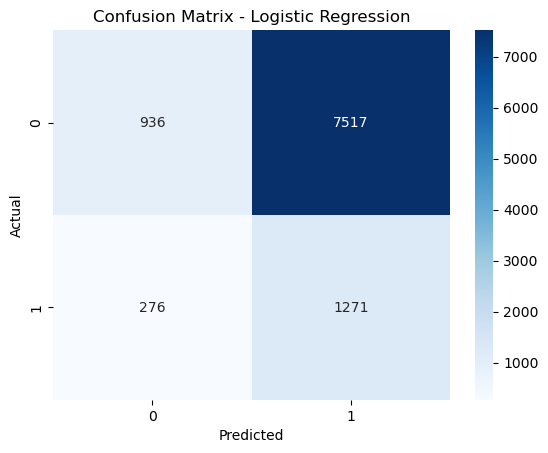


SVM Accuracy: 0.2320
              precision    recall  f1-score   support

           0       0.79      0.13      0.22      8453
           1       0.15      0.81      0.25      1547

    accuracy                           0.23     10000
   macro avg       0.47      0.47      0.23     10000
weighted avg       0.69      0.23      0.22     10000



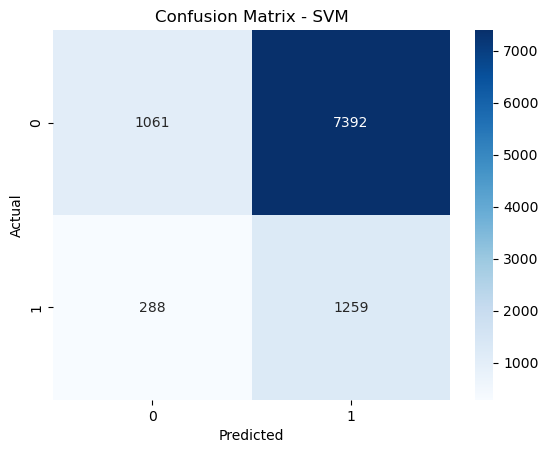


XGBoost Accuracy: 0.1727
              precision    recall  f1-score   support

           0       0.71      0.04      0.07      8453
           1       0.15      0.92      0.26      1547

    accuracy                           0.17     10000
   macro avg       0.43      0.48      0.16     10000
weighted avg       0.62      0.17      0.10     10000



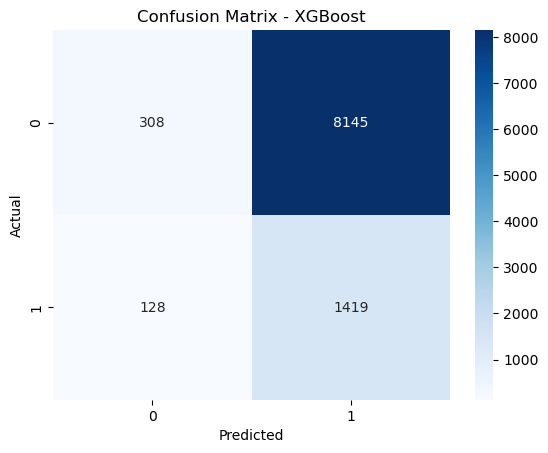


CNN Accuracy: 0.6168
              precision    recall  f1-score   support

           0       0.85      0.67      0.75      8453
           1       0.16      0.34      0.21      1547

    accuracy                           0.62     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.74      0.62      0.66     10000



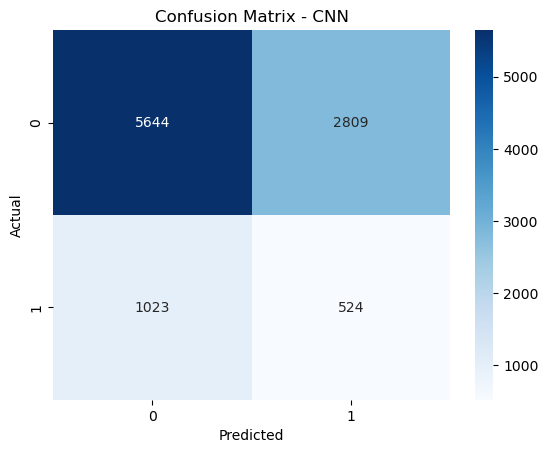


RNN Accuracy: 0.6168
              precision    recall  f1-score   support

           0       0.85      0.67      0.75      8453
           1       0.16      0.34      0.21      1547

    accuracy                           0.62     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.74      0.62      0.66     10000



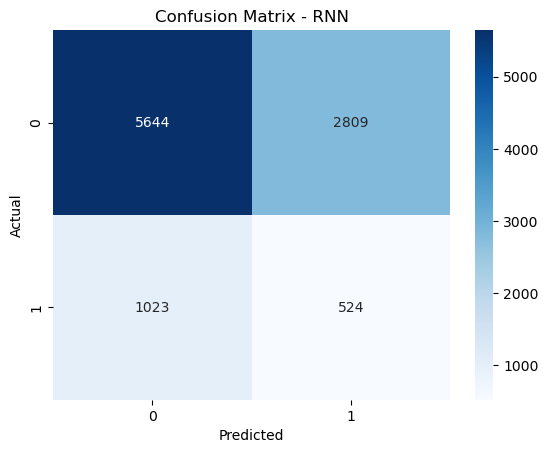


LSTM Accuracy: 0.6089
              precision    recall  f1-score   support

           0       0.84      0.66      0.74      8453
           1       0.15      0.31      0.20      1547

    accuracy                           0.61     10000
   macro avg       0.49      0.49      0.47     10000
weighted avg       0.73      0.61      0.66     10000



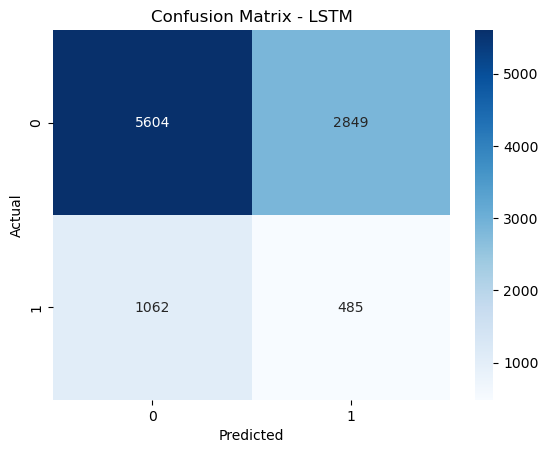


DistilBERT Accuracy: 0.8350
              precision    recall  f1-score   support

           0       0.98      0.83      0.89      8453
           1       0.48      0.89      0.62      1547

    accuracy                           0.83     10000
   macro avg       0.73      0.86      0.76     10000
weighted avg       0.90      0.83      0.85     10000



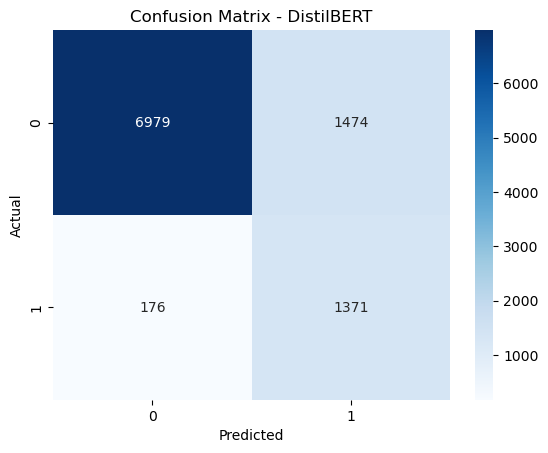


VADER Accuracy: 0.8770
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      8453
           1       0.67      0.41      0.50      1547

    accuracy                           0.88     10000
   macro avg       0.78      0.68      0.72     10000
weighted avg       0.86      0.88      0.86     10000



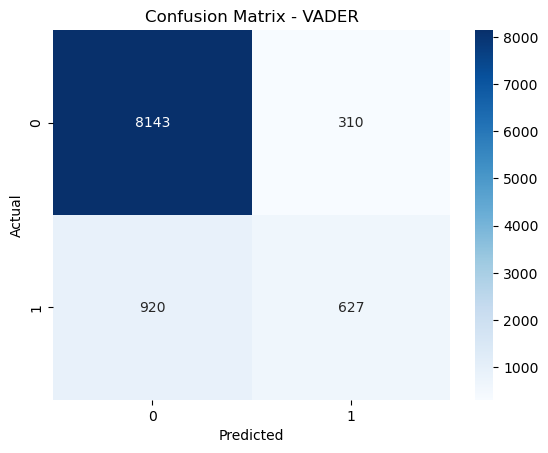


Ensemble Accuracy: 0.6501
              precision    recall  f1-score   support

           0       0.90      0.65      0.76      8453
           1       0.25      0.62      0.36      1547

    accuracy                           0.65     10000
   macro avg       0.58      0.64      0.56     10000
weighted avg       0.80      0.65      0.70     10000



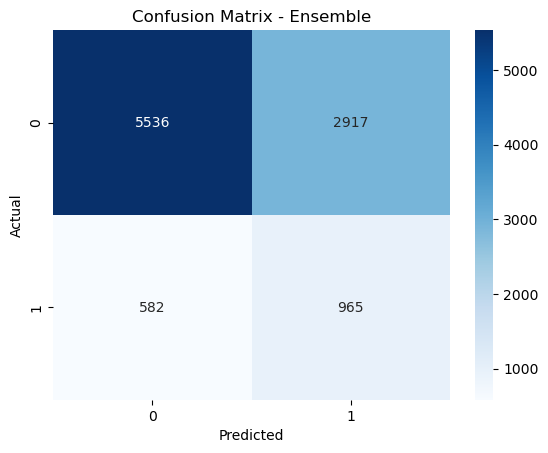

In [34]:
# Evaluate each
model_names = ["Logistic Regression", "SVM", "XGBoost", "CNN", "RNN", "LSTM", "DistilBERT", "VADER", "Ensemble"]
model_preds = [lr_preds, svm_preds, xgb_preds, cnn_preds, rnn_preds, lstm_preds, distilbert_preds, vader_preds, ensemble_preds]

for name, pred in zip(model_names, model_preds):
    evaluate(name, y, pred)

In [45]:
y_true        = np.load("predictions/y_true.npy")

In [46]:
np.save("predictions/lr_preds.npy", lr_preds)
np.save("predictions/svm_preds.npy", svm_preds)
np.save("predictions/xgb_preds.npy", xgb_preds)

np.save("predictions/cnn_preds.npy", cnn_preds)
np.save("predictions/rnn_preds.npy", rnn_preds)
np.save("predictions/lstm_preds.npy", lstm_preds)

np.save("predictions/roberta_preds.npy", distilbert_preds)
np.save("predictions/vader_preds.npy", vader_preds)
np.save("predictions/y_true.npy", y)  # Save ground truth

In [47]:
# Bundle
all_preds = [lr_preds, svm_preds, xgb_preds, cnn_preds, rnn_preds, lstm_preds, distilbert_preds, vader_preds]
model_names = ["LR", "SVM", "XGB", "CNN", "RNN", "LSTM", "DISTILBERT", "VADER"]

In [49]:
from itertools import combinations
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
import numpy as np

results = []

def majority_voting(preds):
    stacked = np.vstack(preds)
    final_preds, _ = mode(stacked, axis=0)
    return final_preds.flatten()

def weighted_voting(preds, weights=None):
    preds = np.array(preds)
    if weights is None:
        weights = [1] * len(preds)
    weighted_sum = np.average(preds, axis=0, weights=weights)
    return (weighted_sum > 0.5).astype(int)

def blending_ensemble(preds, y_true):
    X_blend = np.vstack(preds).T
    model = LogisticRegression()
    model.fit(X_blend, y_true)
    return model.predict(X_blend)

# Loop through combinations from size 3 to 8
for r in range(3, len(all_preds) + 1):
    for indices in combinations(range(len(all_preds)), r):
        selected_preds = [all_preds[i] for i in indices]
        selected_names = [model_names[i] for i in indices]
        name_key = "+".join(selected_names)

        # --- Majority Voting ---
        mv_preds = majority_voting(selected_preds)
        mv_acc = accuracy_score(y_true, mv_preds)
        mv_f1 = f1_score(y_true, mv_preds)
        results.append({
            "Models": name_key,
            "Ensemble_Type": "Majority",
            "Accuracy": mv_acc,
            "F1_Score": mv_f1
        })

        # --- Weighted Voting ---
        weights = [1] * r  # Equal weights for now
        wv_preds = weighted_voting(selected_preds, weights)
        wv_acc = accuracy_score(y_true, wv_preds)
        wv_f1 = f1_score(y_true, wv_preds)
        results.append({
            "Models": name_key,
            "Ensemble_Type": "Weighted",
            "Accuracy": wv_acc,
            "F1_Score": wv_f1
        })

        # --- Blending (Logistic Regression) ---
        try:
            blend_preds = blending_ensemble(selected_preds, y_true)
            blend_acc = accuracy_score(y_true, blend_preds)
            blend_f1 = f1_score(y_true, blend_preds)
            results.append({
                "Models": name_key,
                "Ensemble_Type": "Blending",
                "Accuracy": blend_acc,
                "F1_Score": blend_f1
            })
        except Exception as e:
            print(f"❌ Blending failed for {name_key}: {e}")

In [50]:
import pandas as pd
import os

# Save all results
os.makedirs("results", exist_ok=True)
df = pd.DataFrame(results)
df.to_csv("results/all_ensemble_combinations.csv", index=False)
print("\n Saved all results to results/all_ensemble_combinations.csv")

# Select the best
best = df.sort_values(by="Accuracy", ascending=False).iloc[0]
print("\n Best Ensemble Combination Found:\n", best)

# Save the best predictions for Streamlit
best_models = best["Models"].split("+")
best_indices = [model_names.index(m) for m in best_models]
best_preds = [all_preds[i] for i in best_indices]

if best["Ensemble_Type"] == "Majority":
    final_preds = majority_voting(best_preds)
elif best["Ensemble_Type"] == "Weighted":
    final_preds = weighted_voting(best_preds)
else:
    final_preds = blending_ensemble(best_preds, y_true)

np.save("predictions/best_ensemble_preds.npy", final_preds)
print("\n Saved best predictions to predictions/best_ensemble_preds.npy")


 Saved all results to results/all_ensemble_combinations.csv

 Best Ensemble Combination Found:
 Models           LR+SVM+XGB+CNN+RNN+LSTM+DISTILBERT+VADER
Ensemble_Type                                    Blending
Accuracy                                           0.8883
F1_Score                                         0.540518
Name: 656, dtype: object

 Saved best predictions to predictions/best_ensemble_preds.npy


In [56]:
import pandas as pd

results_df = pd.DataFrame(results)

In [57]:
# Sort by F1 Score (you can change to 'Accuracy' if you prefer)
top_results = results_df.sort_values(by="F1_Score", ascending=False)

In [58]:
# Show top 10 ensembles
top_results.head(10)

,Models,Ensemble_Type,Accuracy,F1_Score
136,XGB+DISTILBERT+VADER,Weighted,0.8249,0.603218
135,XGB+DISTILBERT+VADER,Majority,0.8249,0.603218
60,LR+DISTILBERT+VADER,Majority,0.8280,0.594531
61,LR+DISTILBERT+VADER,Weighted,0.8280,0.594531
106,SVM+DISTILBERT+VADER,Weighted,0.8277,0.593536
105,SVM+DISTILBERT+VADER,Majority,0.8277,0.593536
301,SVM+XGB+DISTILBERT+VADER,Weighted,0.8255,0.576970
300,SVM+XGB+DISTILBERT+VADER,Majority,0.8255,0.576970
241,LR+XGB+DISTILBERT+VADER,Weighted,0.8249,0.576951
240,LR+XGB+DISTILBERT+VADER,Majority,0.8249,0.576951


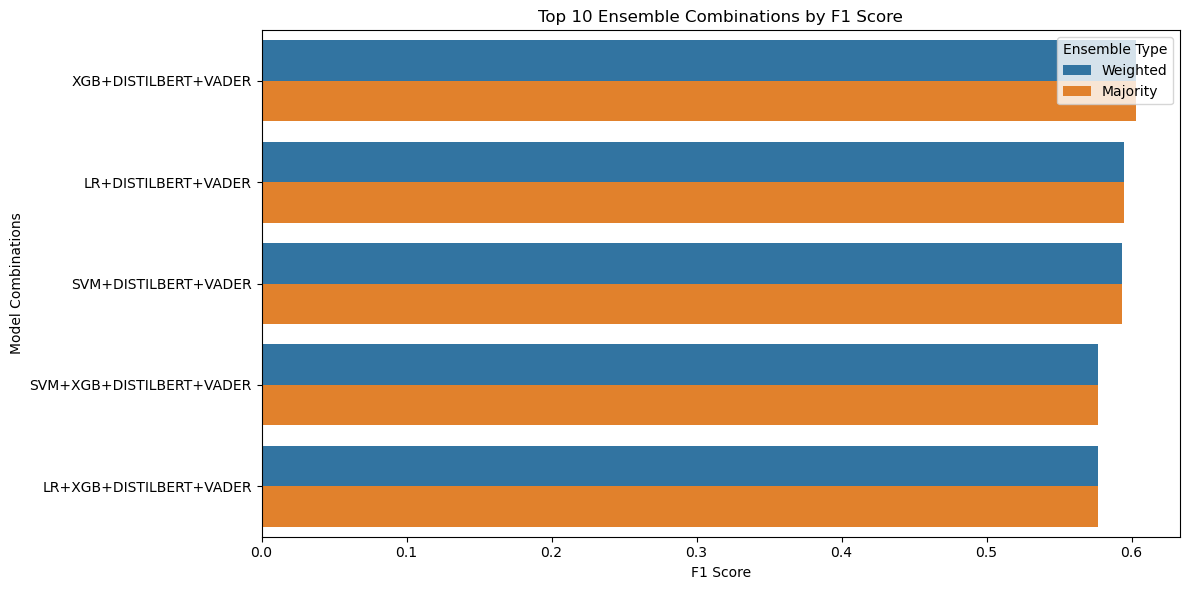

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(data=top_results.head(10), x="F1_Score", y="Models", hue="Ensemble_Type")
plt.title("Top 10 Ensemble Combinations by F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model Combinations")
plt.legend(title="Ensemble Type")
plt.tight_layout()
plt.show()

C:\Users\ATHAK\AppData\Local\Temp\ipykernel_6516\3204085597.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x="Ensemble_Type", y="F1_Score", palette="Set2")


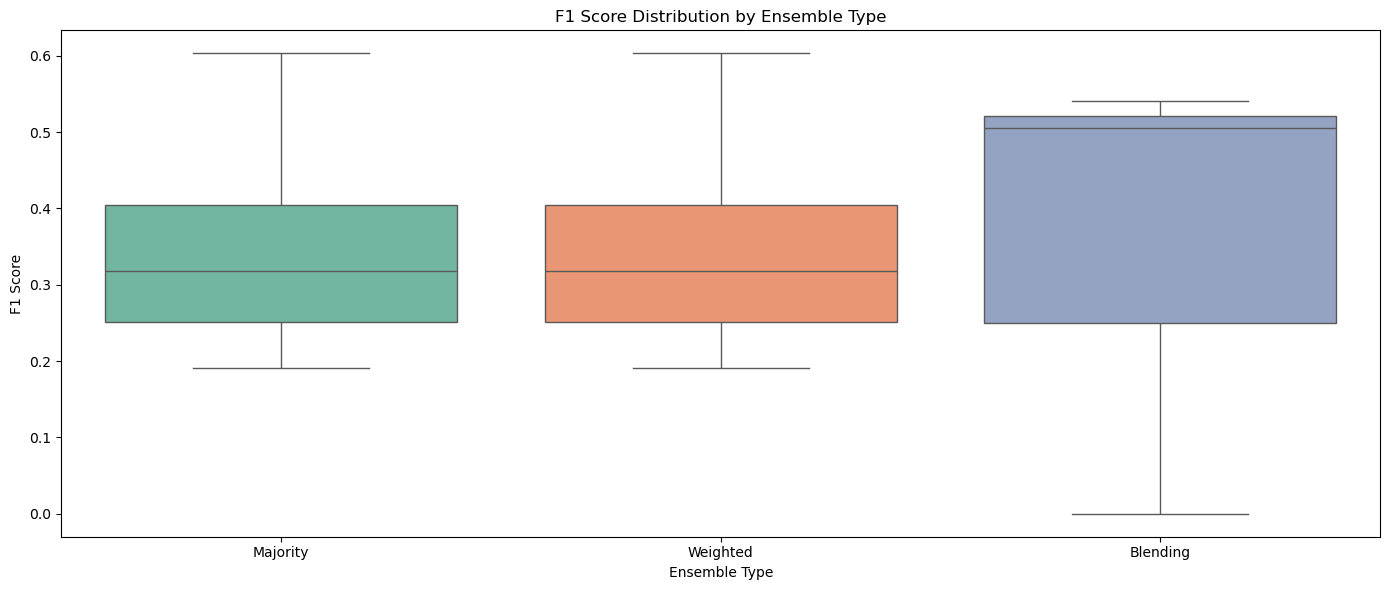

In [60]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=results_df, x="Ensemble_Type", y="F1_Score", palette="Set2")
plt.title("F1 Score Distribution by Ensemble Type")
plt.xlabel("Ensemble Type")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

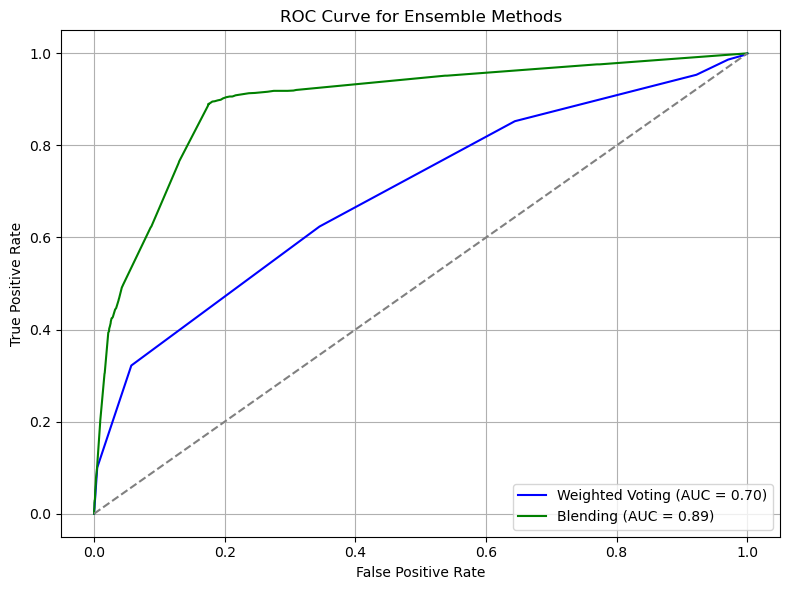

In [61]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Weighted Voting Probabilities
def weighted_probs(preds, weights=None):
    preds = np.array(preds)
    if weights is None:
        weights = [1] * len(preds)
    return np.average(preds, axis=0, weights=weights)  # returns probability

# Blending Probabilities
def blending_probs(preds, y_true):
    X_blend = np.vstack(preds).T
    model = LogisticRegression()
    model.fit(X_blend, y_true)
    return model.predict_proba(X_blend)[:, 1]  # Probability of class 1

# Get probability outputs
wv_probs = weighted_probs(all_preds)
blend_probs = blending_probs(all_preds, y_true)

# Compute ROC values
fpr_wv, tpr_wv, _ = roc_curve(y_true, wv_probs)
roc_auc_wv = auc(fpr_wv, tpr_wv)

fpr_blend, tpr_blend, _ = roc_curve(y_true, blend_probs)
roc_auc_blend = auc(fpr_blend, tpr_blend)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_wv, tpr_wv, color='blue', label=f'Weighted Voting (AUC = {roc_auc_wv:.2f})')
plt.plot(fpr_blend, tpr_blend, color='green', label=f'Blending (AUC = {roc_auc_blend:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Ensemble Methods')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()